# Tutorial 2: Running `floodsr tohr`

**What you'll do:**
- Install the extended `floodsr` stack for this notebook session
- Download and visualize a test tile
- Run `floodsr tohr` from the CLI and compare a few options

For the full install matrix outside notebooks, see {doc}`../installation`.

## 1. Setup

This notebook adapts the recommended **extended install** pattern to the active Jupyter kernel:

1. install the GDAL-backed stack with `conda`
2. install `floodsr` with `pip` into that same environment

The extra notebook packages used below are installed at the same time so the cells stay self-contained.

In [1]:
!conda install -n base -c conda-forge python=3.12 gdal rasterio matplotlib numpy -y -q
!python -m pip install --quiet floodsr

Channels:
 - conda-forge
Platform: linux-64

done
Solving environment: ...working... 

done

## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - gdal
    - matplotlib
    - numpy
    - python=3.12
    - rasterio


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    affine-2.4.0               |     pyhd8ed1ab_1          19 KB  conda-forge
    alsa-lib-1.2.15.3          |       hb03c661_0         571 KB  conda-forge
    attrs-25.4.0               |     pyhcf101f3_1          63 KB  conda-forge
    blosc-1.21.6               |       he440d0b_1          47 KB  conda-forge
    brotli-1.1.0               |       hb9d3cd8_3          19 KB  conda-forge
    brotli-bin-1.1.0           |       hb9d3cd8_3          19 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    cairo-1.18.4               |       h3394656_0         955 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  cond

Preparing transaction: ...working... 

done
Verifying transaction: ...working... 

done
Executing transaction: ...working... 

done


In [2]:
!floodsr doctor

onnxruntime_installed=True
onnxruntime_version=1.24.4
onnxruntime_available_providers=AzureExecutionProvider,CPUExecutionProvider
rasterio_installed=True
rasterio_version=1.5.0
gdal_python_installed=True
gdal_python_version=GDAL 3.10.3, released 2025/04/01
gdal_config_installed=True
gdal_config_version=3.10.3
gdal_vrt_enabled=True


## 2. Download Test Data

We use the Dudelange tile from the `v0.0.6` release. It has a 13 MB DEM large enough to exercise the GDAL-backed extended workflow.

In [3]:
!curl -L --silent --show-error -O https://github.com/cefect/floodsr/releases/download/v0.0.6/lowres030.tif
!curl -L --silent --show-error -O https://github.com/cefect/floodsr/releases/download/v0.0.6/hires003_dem.tif

## 3. Visualize the Inputs

In [4]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt


def load_band(path):
    """Load one raster band and convert nodata to NaN."""
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
    if nodata is not None:
        data[data == nodata] = np.nan
    return data


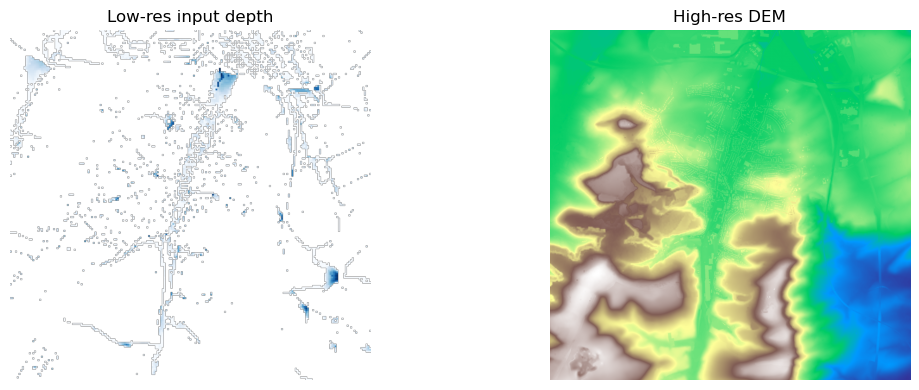

LR depth shape: (203, 209)
DEM shape:      (2030, 2090)


In [5]:
lowres = load_band("lowres030.tif")
dem = load_band("hires003_dem.tif")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(np.where(lowres > 0, lowres, np.nan), cmap="Blues")
axes[0].set_title("Low-res input depth")
axes[1].imshow(dem, cmap="terrain")
axes[1].set_title("High-res DEM")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"LR depth shape: {lowres.shape}")
print(f"DEM shape:      {dem.shape}")

## 4. Fetch the Model

Download model weights once, then reuse the cached copy on later runs.

In [6]:
!floodsr models fetch --no-progress ResUNet_16x_DEM

INFO:floodsr.model_registry:attempting unauthenticated model download from
    https://github.com/cefect/floodsr/releases/download/v2026.02.19/model_infer.onnx


/root/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx


## 5. Run `tohr`

The basic call takes a low-res depth raster with `--in` and a high-res DEM with `--dem`.

In [7]:
!floodsr tohr --in lowres030.tif --dem hires003_dem.tif --out result.tif

INFO:floodsr.cli:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16


INFO:floodsr.cli:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /root/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /tmp/floodsr-platform-prep-17rjqkq4/lowres030_platform_depth.tif
platform_dem_hr
    /tmp/floodsr-platform-prep-17rjqkq4/hires003_dem_platform_dem.tif
output
    /workspace/docs/user/notebooks/result.tif


INFO:floodsr.cli:platform-preprocessed inputs
  depth_lr shape=(203, 209) res=(30.0, 30.0) m/pix
  dem_hr shape=(2030, 2090) res=(3.0, 3.0) m/pix


INFO:floodsr.cli:model preprocessing complete
  scale=16 (HR/LR ratio)
  crs_policy=strict
  aligned depth shape=(203, 209) resampled=True
  aligned dem shape=(3248, 3344) raw_dem_shape=(2030, 2090)
  max_depth=5.0 dem_pct_clip=95.0
INFO:floodsr.cli:prepared inputs summary:
  aligned depth_lr shape=(203, 209) res=(30.0, 30.0) m/pix
  aligned dem_hr shape=(3248, 3344) res=(1.875, 1.875) m/pix
  max_depth=5.0
  dem_pct_clip=95.0
INFO:floodsr.cli:window config
  method=feather
  overlap_lr=8
  overlap_hr=128
  tile_size_lr=32
  tile_size_hr=512
INFO:floodsr.cli:running feather tiling over 9x9 grid
  stride_hr=384
  overlap_hr=128
feather pass:   0%|                                  | 0/81 [00:00<?, ?window/s]

feather pass:   2%|▋                         | 2/81 [00:00<00:04, 18.75window/s]

...

feather pass:  88%|█████████████████████▉   | 71/81 [00:01<00:00, 40.27window/s]

feather pass:  94%|███████████████████████▍ | 76/81 [00:02<00:00, 40.51window/s]

feather pass: 100%|█████████████████████████| 81/81 [00:02<00:00, 37.52window/s]


INFO:floodsr.cli:post-resampling model output from (3248, 3344) to (2030, 2090) on raw DEM grid with bilinear interpolation.


INFO:floodsr.cli:finished tohr inference in 2.847s; wrote 6,470,873 bytes to
    /workspace/docs/user/notebooks/result.tif
/workspace/docs/user/notebooks/result.tif


## 5.1 Visualize the output

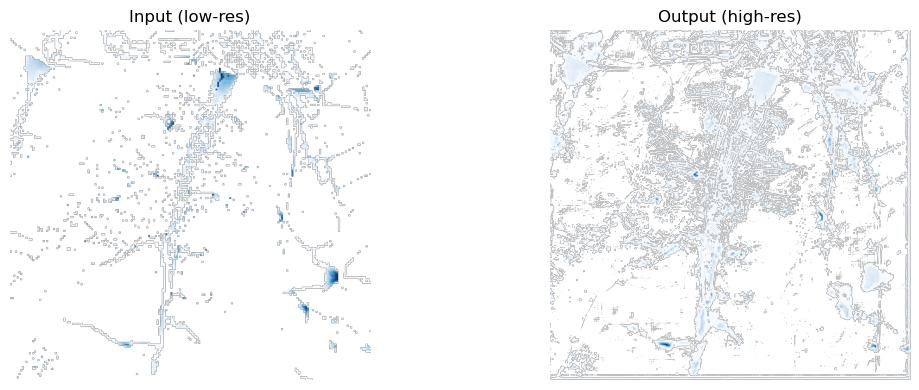

In [8]:
result = load_band("result.tif")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(np.where(lowres > 0, lowres, np.nan), cmap="Blues")
axes[0].set_title("Input (low-res)")
axes[1].imshow(np.where(result > 0, result, np.nan), cmap="Blues")
axes[1].set_title("Output (high-res)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Explore `--max-depth`

This controls the maximum depth used for log-space scaling during inference. Lowering it compresses the depth range relative to the default training statistics.

In [9]:
!floodsr tohr --in lowres030.tif --dem hires003_dem.tif --out result_maxdepth.tif --max-depth 1.5

INFO:floodsr.cli:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16


INFO:floodsr.cli:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /root/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /tmp/floodsr-platform-prep-038mitxu/lowres030_platform_depth.tif
platform_dem_hr
    /tmp/floodsr-platform-prep-038mitxu/hires003_dem_platform_dem.tif
output
    /workspace/docs/user/notebooks/result_maxdepth.tif


INFO:floodsr.cli:platform-preprocessed inputs
  depth_lr shape=(203, 209) res=(30.0, 30.0) m/pix
  dem_hr shape=(2030, 2090) res=(3.0, 3.0) m/pix


INFO:floodsr.cli:model preprocessing complete
  scale=16 (HR/LR ratio)
  crs_policy=strict
  aligned depth shape=(203, 209) resampled=True
  aligned dem shape=(3248, 3344) raw_dem_shape=(2030, 2090)
  max_depth=1.5 dem_pct_clip=95.0
INFO:floodsr.cli:prepared inputs summary:
  aligned depth_lr shape=(203, 209) res=(30.0, 30.0) m/pix
  aligned dem_hr shape=(3248, 3344) res=(1.875, 1.875) m/pix
  max_depth=1.5
  dem_pct_clip=95.0
INFO:floodsr.cli:window config
  method=feather
  overlap_lr=8
  overlap_hr=128
  tile_size_lr=32
  tile_size_hr=512


INFO:floodsr.cli:running feather tiling over 9x9 grid
  stride_hr=384
  overlap_hr=128
feather pass:   0%|                                  | 0/81 [00:00<?, ?window/s]

...

feather pass:  99%|████████████████████████▋| 80/81 [00:02<00:00, 39.79window/s]

feather pass: 100%|█████████████████████████| 81/81 [00:02<00:00, 37.73window/s]


INFO:floodsr.cli:post-resampling model output from (3248, 3344) to (2030, 2090) on raw DEM grid with bilinear interpolation.


INFO:floodsr.cli:finished tohr inference in 2.923s; wrote 7,185,448 bytes to
    /workspace/docs/user/notebooks/result_maxdepth.tif


/workspace/docs/user/notebooks/result_maxdepth.tif


## 6.1 Visualize `--max-depth`

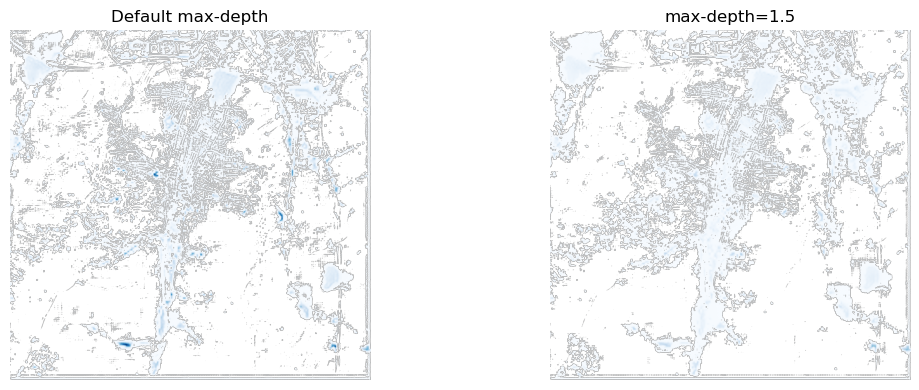

In [10]:
result_maxdepth = load_band("result_maxdepth.tif")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vmax = max(np.nanmax(result), np.nanmax(result_maxdepth))
axes[0].imshow(np.where(result > 0, result, np.nan), cmap="Blues", vmin=0, vmax=vmax)
axes[0].set_title("Default max-depth")
axes[1].imshow(np.where(result_maxdepth > 0, result_maxdepth, np.nan), cmap="Blues", vmin=0, vmax=vmax)
axes[1].set_title("max-depth=1.5")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Explore `--window-method`

This controls how tiled outputs are stitched together:

| Value | Behaviour |
|-------|-----------|
| `feather` | *(default)* blends tile edges using weighted overlap |
| `hard` | places tiles without blending, which is faster but may show seams |

In [11]:
!floodsr tohr --in lowres030.tif --dem hires003_dem.tif --out result_hard.tif --window-method hard

INFO:floodsr.cli:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16


INFO:floodsr.cli:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /root/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /tmp/floodsr-platform-prep-bekero0_/lowres030_platform_depth.tif
platform_dem_hr
    /tmp/floodsr-platform-prep-bekero0_/hires003_dem_platform_dem.tif
output
    /workspace/docs/user/notebooks/result_hard.tif


INFO:floodsr.cli:platform-preprocessed inputs
  depth_lr shape=(203, 209) res=(30.0, 30.0) m/pix
  dem_hr shape=(2030, 2090) res=(3.0, 3.0) m/pix


INFO:floodsr.cli:model preprocessing complete
  scale=16 (HR/LR ratio)
  crs_policy=strict
  aligned depth shape=(203, 209) resampled=True
  aligned dem shape=(3248, 3344) raw_dem_shape=(2030, 2090)
  max_depth=5.0 dem_pct_clip=95.0
INFO:floodsr.cli:prepared inputs summary:
  aligned depth_lr shape=(203, 209) res=(30.0, 30.0) m/pix
  aligned dem_hr shape=(3248, 3344) res=(1.875, 1.875) m/pix
  max_depth=5.0
  dem_pct_clip=95.0
INFO:floodsr.cli:window config
  method=hard
  overlap_lr=8
  overlap_hr=128
  tile_size_lr=32
  tile_size_hr=512


INFO:floodsr.cli:running hard tiling over 7x7 grid
  overlap_lr=8
  overlap_hr=128
non-overlap pass:   0%|                              | 0/49 [00:00<?, ?window/s]

...

non-overlap pass:  84%|█████████████████▌   | 41/49 [00:01<00:00, 39.62window/s]

non-overlap pass:  94%|███████████████████▋ | 46/49 [00:01<00:00, 39.97window/s]

non-overlap pass: 100%|█████████████████████| 49/49 [00:01<00:00, 38.77window/s]


INFO:floodsr.cli:post-resampling model output from (3248, 3344) to (2030, 2090) on raw DEM grid with bilinear interpolation.


INFO:floodsr.cli:finished tohr inference in 2.032s; wrote 6,769,772 bytes to
    /workspace/docs/user/notebooks/result_hard.tif
/workspace/docs/user/notebooks/result_hard.tif


## 7.1 Visualize `--window-method`

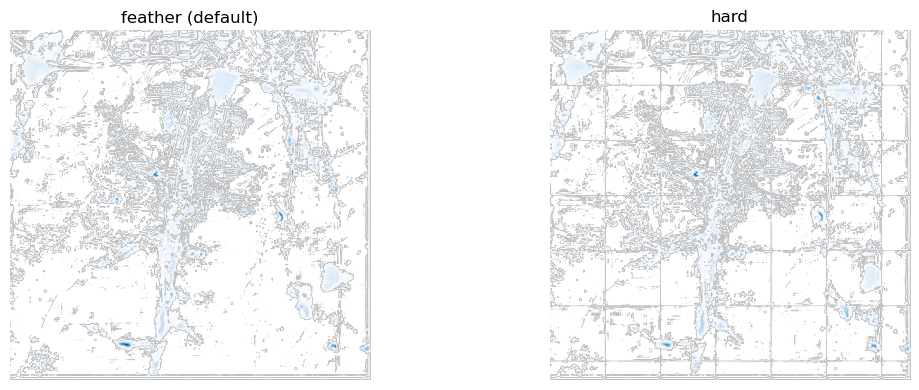

In [12]:
result_hard = load_band("result_hard.tif")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vmax = max(np.nanmax(result), np.nanmax(result_hard))
axes[0].imshow(np.where(result > 0, result, np.nan), cmap="Blues", vmin=0, vmax=vmax)
axes[0].set_title("feather (default)")
axes[1].imshow(np.where(result_hard > 0, result_hard, np.nan), cmap="Blues", vmin=0, vmax=vmax)
axes[1].set_title("hard")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Other `tohr` Arguments

The remaining options are covered in the [CLI reference](https://floodsr.readthedocs.io/en/latest/cli_reference.html).

| Argument | Description |
|----------|-------------|
| `--out` | Output path. Defaults to `./<input_stem>_sr` with the same extension. |
| `--model-version` | Model version key (for example `ResUNet_16x_DEM`). |
| `--model-path` | Explicit local `.onnx` path, bypassing the registry. |
| `--cache-dir` | Override the model cache directory. |
| `--force` | Force model redownload even if a cached copy exists. |
| `--tile-size` | Low-res tile size override. |
| `--tile-overlap` | Feather overlap in low-res pixels. |
| `--dem-pct-clip` | DEM percentile clip override when training stats are incomplete. |
| `--crs-policy` | CRS mismatch policy between depth and DEM. |
| `-v` / `-q` | Increase or decrease log verbosity. |

Run `floodsr tohr --help` for the full up-to-date list.